## Analyse Consommation

#### Setup du workspace

In [1]:
# Import des librairies standard
import os
import numpy as np
import pandas as pd
from datetime import datetime
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# Import des librairies DS
import spacy
import sklearn

In [3]:
# Import des modules perso
from utils import TransformData

In [4]:
# Defining workspace
base_directory = '/home/onyxia/work/project'
data_directory = os.path.join(base_directory, '1-data')
data_training_directory = os.path.join(data_directory, 'training')
data_test_directory = os.path.join(data_directory, 'test')
data_evaluation_directory = os.path.join(data_directory, 'evaluation')
data_additional_directory = os.path.join(data_directory, 'additional')
eda_directory = os.path.join(base_directory, '2-eda')
models_directory = os.path.join(base_directory, '3-models')

In [5]:
# Defining files
file_conso = os.path.join(data_training_directory, "apprentissage_consommations_2023_11.csv")
file_portfeuille = os.path.join(data_training_directory, "apprentissage_portefeuille_2023_11.csv")
file_interaction = os.path.join(data_training_directory, "apprentissage_interactions_2023_11.csv")
file_impayes = os.path.join(data_training_directory, "apprentissage_impayes_2023_11.csv")
file_reclamations = os.path.join(data_training_directory, "apprentissage_reclamations_2023_11.csv")
file_dictionnaire = os.path.join(data_additional_directory, "data_challenges_ensae_alptis_dictionnaire_donnees.xlsx")

#### Defining initial data structures

In [6]:
# Dataframes
df_portfolio = pd.read_csv(file_portfeuille, sep=";")
df_conso = pd.read_csv(file_conso, sep=";")
df_interaction = pd.read_csv(file_interaction, sep=";")
df_reclamation = pd.read_csv(file_reclamations, sep=";")
df_impaye = pd.read_csv(file_impayes, sep=";")

# Lists columns
col_portfolio = list(df_portfolio.columns)
col_conso = list(df_conso.columns)
col_interaction = list(df_interaction.columns)
col_reclamation = list(df_reclamation.columns)
col_impaye = list(df_impaye.columns)

# Dictionnaire de variables
with TransformData.FileManager(file_dictionnaire, "portefeuille") as file:
    variable_dictionnary_portfolio = dict(zip(file.iloc[:,0], file.iloc[:,1]))

/tmp/ipykernel_374502/1750901685.py:2: DtypeWarning: Columns (31,33) have mixed types. Specify dtype option on import or set low_memory=False.
  df_portfolio = pd.read_csv(file_portfeuille, sep=";")


#### Overview

The goal of this section is to build an in-depth understanding of the data structure. This job encompasses :
-   Analyze the size of the dataset
-   The data type issues (categorical variables considered as numeric or vice-versa)
-   Evaluate the extent and impact of missing values and strategies to deal with them
-   Analyze the distribution of variables and strategies to group them in a coherent manner
-   Visualize variables individually

**Dataset structure**

In [7]:
# Describe the dataset
df_conso.shape

(917832, 40)

-   The conso dataset contains one line per client and per month of consumption. In other words, for a given customer, no consumption over the period dec 22 - nov 23 means no line in this dataset.
-   Consumption in this context means the occurrence of a medical event and reimbursement by Alptis

In [8]:
# Describe the dataset
TransformData.grouptype(df_conso)

{'int64': ['client_code'],
 'object': ['annee_mois_paiement'],
 'float64': ['nb_decomptes',
  'nb_decomptes_hospitalisation',
  'nb_decomptes_soins_medicaux',
  'nb_decomptes_pharmacie',
  'nb_decomptes_optique',
  'nb_decomptes_dentaire',
  'nb_decomptes_divers',
  'nb_jours_forfait_journalier',
  'nb_jours_chambre_particuliere',
  'nb_protheses_dentaires',
  'remb_alptis',
  'remb_alptis_hospitalisation',
  'remb_alptis_soins_medicaux',
  'remb_alptis_pharmacie',
  'remb_alptis_optique',
  'remb_alptis_dentaire',
  'remb_alptis_divers',
  'remb_ro',
  'remb_ro_hospitalisation',
  'remb_ro_soins_medicaux',
  'remb_ro_pharmacie',
  'remb_ro_optique',
  'remb_ro_dentaire',
  'remb_ro_divers',
  'frais_reels',
  'frais_reels_hospitalisation',
  'frais_reels_soins_medicaux',
  'frais_reels_pharmacie',
  'frais_reels_optique',
  'frais_reels_dentaire',
  'frais_reels_divers',
  'reste_a_charge',
  'reste_a_charge_hospitalisation',
  'reste_a_charge_soins_medicaux',
  'reste_a_charge_pharma

Raw dataset contains three types of data :
-   *int* : client code is considered here as an integer - we will categorize this variable
-   *float64* : The scheme is the same. Some variables are pure floats, some other should be classified integer and the remaining as categorical.
-   *object* : The variable 'annee_mois_paiement' is considered as string. We will create a datetime object instead, all dates set to the end/beginning of the month.

In [9]:
# Format the variables
## str
df_conso['client_code'] = df_conso['client_code'].astype(str)

## int
df_conso['nb_decomptes_hospitalisation'] = df_conso['nb_decomptes_hospitalisation'].astype(int)
df_conso['nb_decomptes_soins_medicaux'] = df_conso['nb_decomptes_soins_medicaux'].astype(int)
df_conso['nb_decomptes_pharmacie'] = df_conso['nb_decomptes_pharmacie'].astype(int)
df_conso['nb_decomptes_optique'] = df_conso['nb_decomptes_optique'].astype(int)
df_conso['nb_decomptes_dentaire'] = df_conso['nb_decomptes_dentaire'].astype(int)
df_conso['nb_jours_forfait_journalier'] = df_conso['nb_jours_forfait_journalier'].astype(int)
df_conso['nb_jours_chambre_particuliere'] = df_conso['nb_jours_chambre_particuliere'].astype(int)
df_conso['nb_protheses_dentaires'] = df_conso['nb_protheses_dentaires'].astype(int)
df_conso['nb_decomptes'] = df_conso['nb_decomptes'].astype(int)
df_conso['nb_decomptes_divers'] = df_conso['nb_decomptes_divers'].astype(int)

## datetime
df_conso['annee_mois_paiement'] = pd.to_datetime(df_conso['annee_mois_paiement'], format='%Y-%m') + pd.offsets.MonthEnd(1)

# running data type analysis
TransformData.grouptype(df_conso)

{'object': ['client_code'],
 'datetime64[ns]': ['annee_mois_paiement'],
 'int64': ['nb_decomptes',
  'nb_decomptes_hospitalisation',
  'nb_decomptes_soins_medicaux',
  'nb_decomptes_pharmacie',
  'nb_decomptes_optique',
  'nb_decomptes_dentaire',
  'nb_decomptes_divers',
  'nb_jours_forfait_journalier',
  'nb_jours_chambre_particuliere',
  'nb_protheses_dentaires'],
 'float64': ['remb_alptis',
  'remb_alptis_hospitalisation',
  'remb_alptis_soins_medicaux',
  'remb_alptis_pharmacie',
  'remb_alptis_optique',
  'remb_alptis_dentaire',
  'remb_alptis_divers',
  'remb_ro',
  'remb_ro_hospitalisation',
  'remb_ro_soins_medicaux',
  'remb_ro_pharmacie',
  'remb_ro_optique',
  'remb_ro_dentaire',
  'remb_ro_divers',
  'frais_reels',
  'frais_reels_hospitalisation',
  'frais_reels_soins_medicaux',
  'frais_reels_pharmacie',
  'frais_reels_optique',
  'frais_reels_dentaire',
  'frais_reels_divers',
  'reste_a_charge',
  'reste_a_charge_hospitalisation',
  'reste_a_charge_soins_medicaux',
  're

In [26]:
# Format the variables
df_portfolio['client_code'] = df_portfolio['client_code'].astype(str)
df_portfolio['client_code_postal'] = df_portfolio['client_code_postal'].astype(str).str.zfill(5)
df_portfolio['client_departement'] = df_portfolio['client_departement'].astype(str).str.zfill(2)
df_portfolio['client_departement_avant_changement_12_mois'] = df_portfolio['client_departement_avant_changement_12_mois'].astype(str)
df_portfolio['client_a_garantie_prevoyance'] = df_portfolio['client_a_garantie_prevoyance'].astype(str)
df_portfolio['client_est_contrat_madelin'] = df_portfolio['client_est_contrat_madelin'].astype(str)
df_portfolio['courtier_est_escompte'] = df_portfolio['courtier_est_escompte'].astype(str)
df_portfolio['client_a_conjoint'] = df_portfolio['client_a_conjoint'].astype(str)
df_portfolio['courtier_code_partenaire'] = df_portfolio['courtier_code_partenaire'].astype(str)
df_portfolio['courtier_code_apporteur'] = df_portfolio['courtier_code_apporteur'].astype(str)
df_portfolio['courtier_code_avant_changement_12_mois'] = df_portfolio['courtier_code_avant_changement_12_mois'].astype(str)
df_portfolio['client_nb_enfants'] = df_portfolio['client_nb_enfants'].astype(int)
df_portfolio['client_nb_assures_contrat'] = df_portfolio['client_nb_assures_contrat'].astype(int)

# running data type analysis
TransformData.grouptype(df_portfolio)

{'object': ['client_code',
  'client_sexe_souscripteur',
  'client_ro_souscripteur',
  'client_code_postal',
  'client_departement',
  'client_departement_avant_changement_12_mois',
  'client_a_conjoint',
  'client_structure_familiale',
  'client_a_garantie_prevoyance',
  'client_produit',
  'client_garantie_base',
  'client_garantie_base_plus_options',
  'client_millesime_tarifaire_produit',
  'client_zone_tarifaire',
  'client_type_zone_tarifaire',
  'client_est_contrat_madelin',
  'client_date_debut_effet_garantie',
  'client_mode_paiement',
  'client_frequence_paiement',
  'client_nom_banque',
  'client_nps_date_reponse_n',
  'client_nps_verbatim_n',
  'client_nps_date_reponse_n_moins1',
  'client_nps_verbatim_n_moins1',
  'courtier_code_partenaire',
  'courtier_code_apporteur',
  'courtier_code_avant_changement_12_mois',
  'courtier_reseau_courtage',
  'courtier_segmentation_interne',
  'courtier_type_commission',
  'courtier_est_escompte'],
 'int64': ['client_age_souscripteur',
 

In [10]:
# Check application of datetime format
df_conso['annee_mois_paiement'].unique()

<DatetimeArray>
['2022-12-31 00:00:00', '2023-01-31 00:00:00', '2023-02-28 00:00:00',
 '2023-03-31 00:00:00', '2023-04-30 00:00:00', '2023-05-31 00:00:00',
 '2023-06-30 00:00:00', '2023-07-31 00:00:00', '2023-08-31 00:00:00',
 '2023-09-30 00:00:00', '2023-10-31 00:00:00', '2023-11-30 00:00:00']
Length: 12, dtype: datetime64[ns]

**Dataset overview**

In [11]:
# Print
df_conso.head()

,client_code,annee_mois_paiement,nb_decomptes,nb_decomptes_hospitalisation,nb_decomptes_soins_medicaux,nb_decomptes_pharmacie,nb_decomptes_optique,nb_decomptes_dentaire,nb_decomptes_divers,nb_jours_forfait_journalier,...,frais_reels_optique,frais_reels_dentaire,frais_reels_divers,reste_a_charge,reste_a_charge_hospitalisation,reste_a_charge_soins_medicaux,reste_a_charge_pharmacie,reste_a_charge_optique,reste_a_charge_dentaire,reste_a_charge_divers
0,21736,2022-12-31,2,0,1,1,0,0,0,0,...,0.0,0.0,0.00,0.00,0.0,0.0,0.0,0.0,0.0,0.00
1,22037,2022-12-31,2,0,1,1,0,0,0,0,...,0.0,0.0,0.00,0.00,0.0,0.0,0.0,0.0,0.0,0.00
2,22331,2022-12-31,10,0,4,6,0,0,0,0,...,0.0,0.0,0.00,0.00,0.0,0.0,0.0,0.0,0.0,0.00
3,22604,2022-12-31,2,0,1,0,0,0,1,0,...,0.0,0.0,89.56,50.32,0.0,26.5,0.0,0.0,0.0,23.82
4,22702,2022-12-31,3,1,1,1,0,0,0,1,...,0.0,0.0,0.00,24.00,0.0,24.0,0.0,0.0,0.0,0.00


In [12]:
# Spliting caterorical vs numerical variables
list_categorical = df_conso.select_dtypes(include=["object","bool"]).columns.to_list()
list_numerical = df_conso.select_dtypes(exclude=["object","bool", "datetime"]).columns.to_list()
list_datetime = df_conso.select_dtypes(include=["datetime"]).columns.to_list()

In [13]:
# Spliting caterorical vs numerical variables
list_categorical

['client_code']

In [14]:
# Spliting caterorical vs numerical variables
list_numerical

['nb_decomptes',
 'nb_decomptes_hospitalisation',
 'nb_decomptes_soins_medicaux',
 'nb_decomptes_pharmacie',
 'nb_decomptes_optique',
 'nb_decomptes_dentaire',
 'nb_decomptes_divers',
 'nb_jours_forfait_journalier',
 'nb_jours_chambre_particuliere',
 'nb_protheses_dentaires',
 'remb_alptis',
 'remb_alptis_hospitalisation',
 'remb_alptis_soins_medicaux',
 'remb_alptis_pharmacie',
 'remb_alptis_optique',
 'remb_alptis_dentaire',
 'remb_alptis_divers',
 'remb_ro',
 'remb_ro_hospitalisation',
 'remb_ro_soins_medicaux',
 'remb_ro_pharmacie',
 'remb_ro_optique',
 'remb_ro_dentaire',
 'remb_ro_divers',
 'frais_reels',
 'frais_reels_hospitalisation',
 'frais_reels_soins_medicaux',
 'frais_reels_pharmacie',
 'frais_reels_optique',
 'frais_reels_dentaire',
 'frais_reels_divers',
 'reste_a_charge',
 'reste_a_charge_hospitalisation',
 'reste_a_charge_soins_medicaux',
 'reste_a_charge_pharmacie',
 'reste_a_charge_optique',
 'reste_a_charge_dentaire',
 'reste_a_charge_divers']

In [15]:
# Spliting caterorical vs numerical variables
list_datetime

['annee_mois_paiement']

In [16]:
# Summarize numerical data
df_conso[list_numerical].describe().round(2)

,nb_decomptes,nb_decomptes_hospitalisation,nb_decomptes_soins_medicaux,nb_decomptes_pharmacie,nb_decomptes_optique,nb_decomptes_dentaire,nb_decomptes_divers,nb_jours_forfait_journalier,nb_jours_chambre_particuliere,nb_protheses_dentaires,...,frais_reels_optique,frais_reels_dentaire,frais_reels_divers,reste_a_charge,reste_a_charge_hospitalisation,reste_a_charge_soins_medicaux,reste_a_charge_pharmacie,reste_a_charge_optique,reste_a_charge_dentaire,reste_a_charge_divers
count,917832.00,917832.00,917832.00,917832.00,917832.00,917832.00,917832.00,917832.00,917832.0,917832.00,...,917832.00,917832.00,917832.00,917832.00,917832.00,917832.00,917832.00,917832.00,917832.00,917832.00
mean,3.44,0.07,1.42,1.49,0.05,0.15,0.27,0.33,0.1,0.07,...,19.27,42.24,24.01,39.74,3.89,13.49,0.14,6.21,11.63,4.38
std,2.91,0.33,1.81,1.43,0.25,0.43,0.67,3.07,1.4,0.62,...,106.72,272.06,190.19,7408.96,93.74,7406.56,3.58,49.23,130.48,85.01
min,1.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.0,0.00,...,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
25%,1.00,0.00,0.00,1.00,0.00,0.00,0.00,0.00,0.0,0.00,...,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
50%,3.00,0.00,1.00,1.00,0.00,0.00,0.00,0.00,0.0,0.00,...,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
75%,5.00,0.00,2.00,2.00,0.00,0.00,0.00,0.00,0.0,0.00,...,0.00,0.00,0.00,2.56,0.00,0.00,0.00,0.00,0.00,0.00
max,77.00,16.00,50.00,75.00,6.00,8.00,51.00,246.00,151.0,56.00,...,6516.75,32020.00,37499.87,7092276.40,34752.51,7092276.40,2053.13,6246.75,18014.00,25685.84


The early analysis of numerical data provides us with some leads for in-depth analysis. Let say :
-   Distribution of medical events by type over a year - Are there some months with a peak in medical events ? Some specific medical events type that supplants the other ? 
-   What proportion of customers recorded a medical event ? And how many of them cancelled their contract
-   Could be interesting to use one of 'reste_a_charge' or 'frais_reel' in defining profiles for our customers
-   Looking for the best aggregation strategy to merge this dataset with the customer one


**Numerical Variables Analysis**

In this section, we will deal with numerical variables. Our goal is to build an in-depth understanding of consumption schemes in our dataset

In [17]:
# Aggregate the dataset by datetime
df_conso_datetime = df_conso[list_datetime + list_numerical].groupby(by='annee_mois_paiement').agg('sum').reset_index()
df_conso_datetime['month-year'] = df_conso_datetime['annee_mois_paiement'].dt.to_period('M').astype(str)
df_conso_datetime.head(5)

,annee_mois_paiement,nb_decomptes,nb_decomptes_hospitalisation,nb_decomptes_soins_medicaux,nb_decomptes_pharmacie,nb_decomptes_optique,nb_decomptes_dentaire,nb_decomptes_divers,nb_jours_forfait_journalier,nb_jours_chambre_particuliere,...,frais_reels_dentaire,frais_reels_divers,reste_a_charge,reste_a_charge_hospitalisation,reste_a_charge_soins_medicaux,reste_a_charge_pharmacie,reste_a_charge_optique,reste_a_charge_dentaire,reste_a_charge_divers,month-year
0,2022-12-31,214021,4493,90014,91383,3604,9151,15376,20899,6175,...,2811490.27,1609754.43,2136985.98,220694.23,342327.72,6596.51,429650.50,825091.97,312625.05,2022-12
1,2023-01-31,223136,4411,92371,97115,3089,8911,17239,21827,6389,...,2252978.87,1640674.61,1783320.20,223466.66,350373.22,7462.59,347707.43,588646.19,265664.11,2023-01
2,2023-02-28,213110,4180,90111,90354,3370,8907,16188,20934,6130,...,2613858.29,1440700.58,1947892.42,207152.37,337183.67,8029.87,405027.58,712027.63,278471.30,2023-02
3,2023-03-31,284853,4719,122510,119554,4729,12643,20698,20768,6799,...,3863169.57,1993725.89,3050791.30,303580.07,705284.24,10749.70,567475.73,1054811.51,408890.05,2023-03
4,2023-04-30,244467,3882,101432,105906,3698,10592,18957,18444,5847,...,3299702.97,1790538.33,2330775.45,241388.86,387535.24,9171.78,449869.97,927112.66,315696.94,2023-04


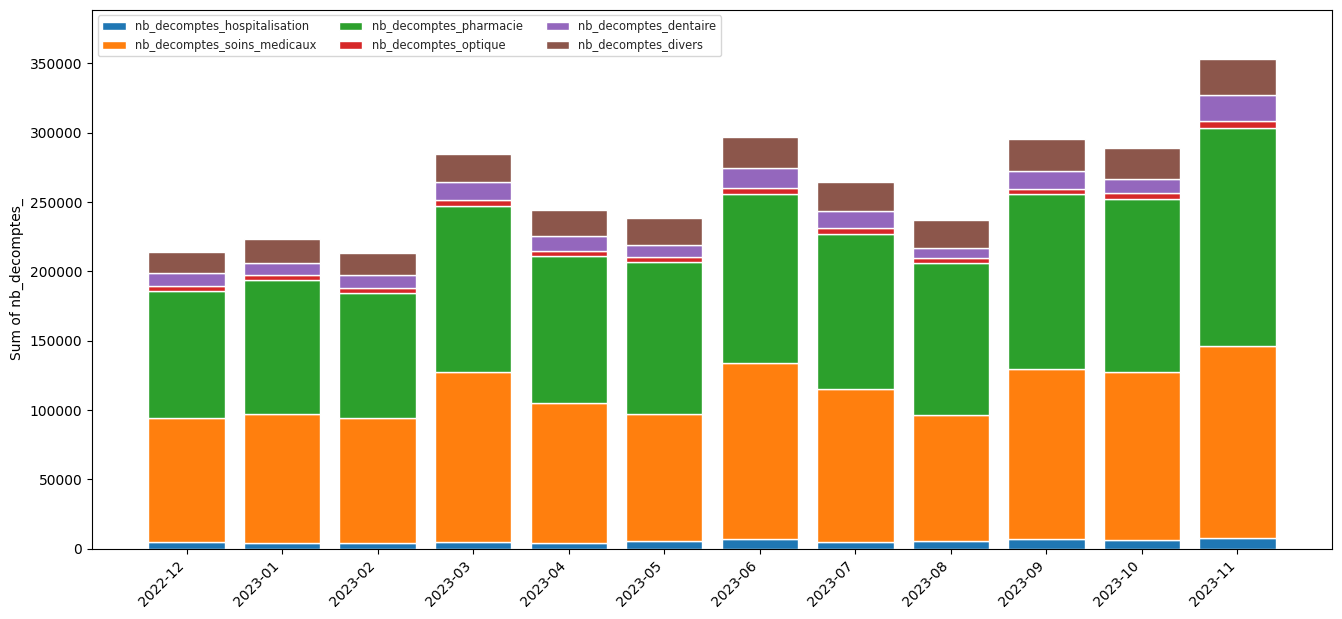

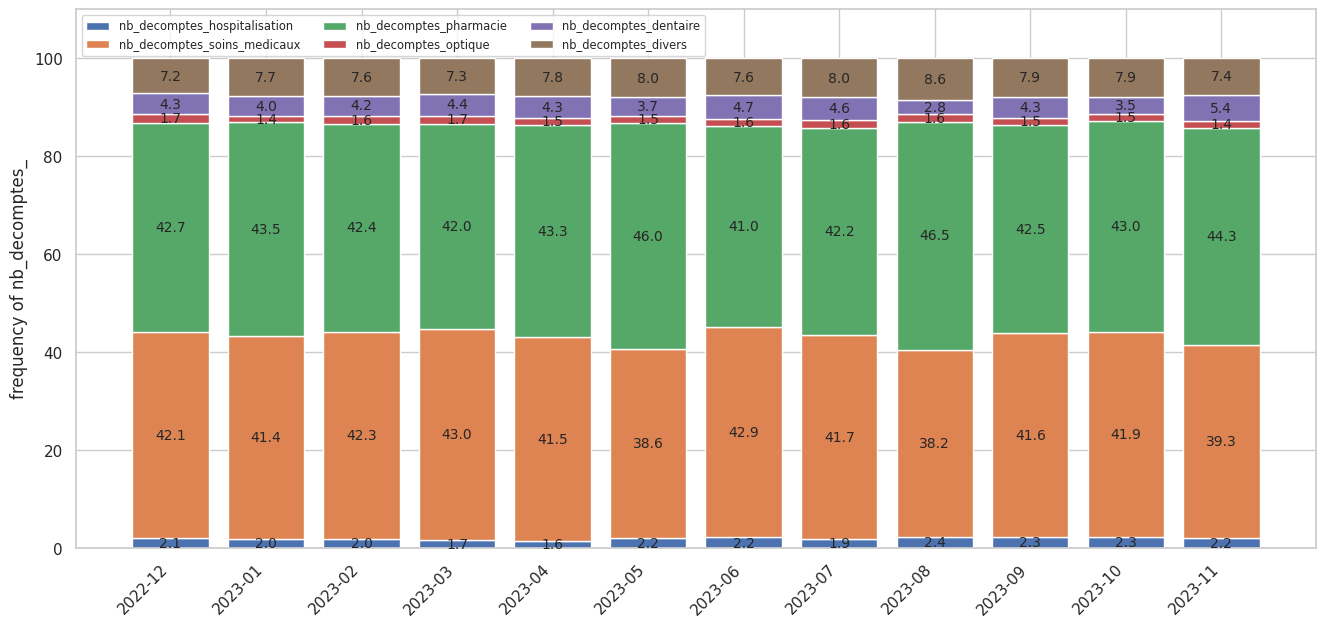

In [18]:
# Plotting the dataset - Analyse des décomptes
TransformData.stacked_bar(data=df_conso_datetime, variable_root_name='nb_decomptes_', x_axis_variable='month-year', type_stack='classic')

Analyse préliminaire :

-   La distribution des décompte présente une certaine saisonnalité. On observe un pic à peu près tous les 3 mois.
-   Le mois de novembre est un mois particulièrement dense en termes de décompte : plusieurs raisons pourraient expliquer : 
    +   Rendez-vous chez le médecin avant les vacances de Noël
    +   Effet rattrapage : accélération dossiers à traiter pour clôturer l'année
    +   etc.
-   Les décomptes pour pharmacie sont majoritaires dans notre jeu de données, et ce, quelque soit le mois. Ils sont suivi des soins médicaux.
-   En d'autres termes, les notifications concernent majoritairement (+ 80%) des actes de soins médicaux et de pharmacie.
-   Certain respect des proportions mois après mois.
-   Légère baisse de la proportion de décomptes pour soins médicaux en mai et en août et en novembre. 

__

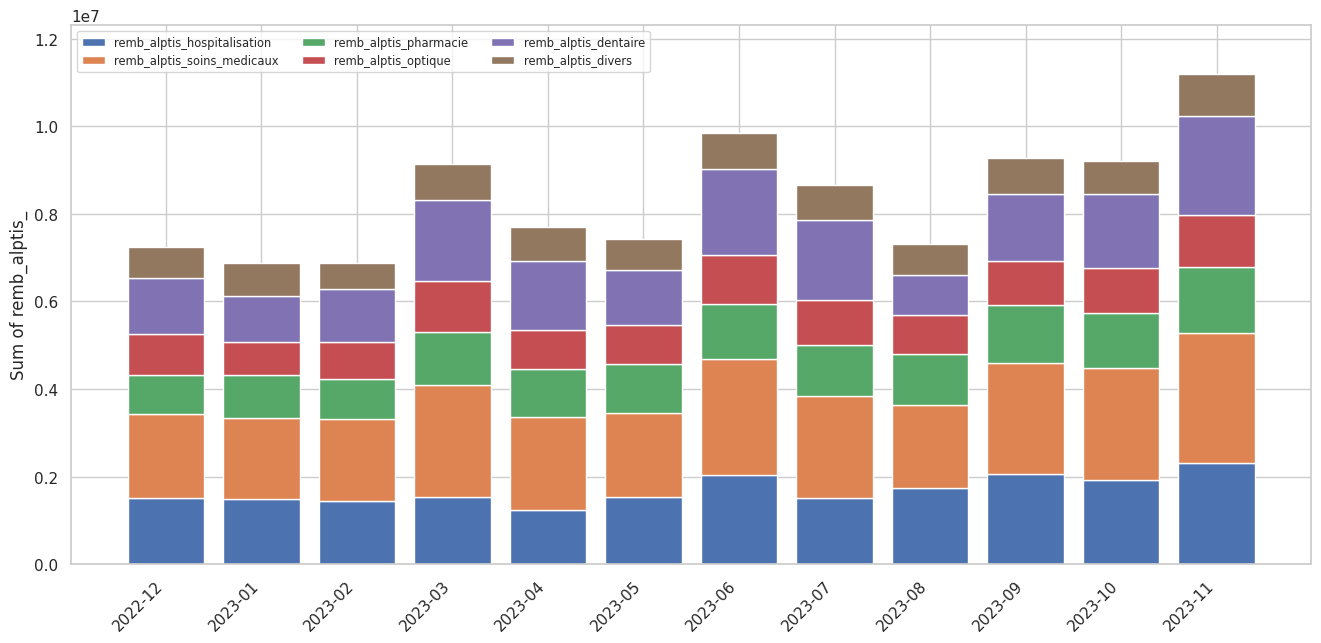

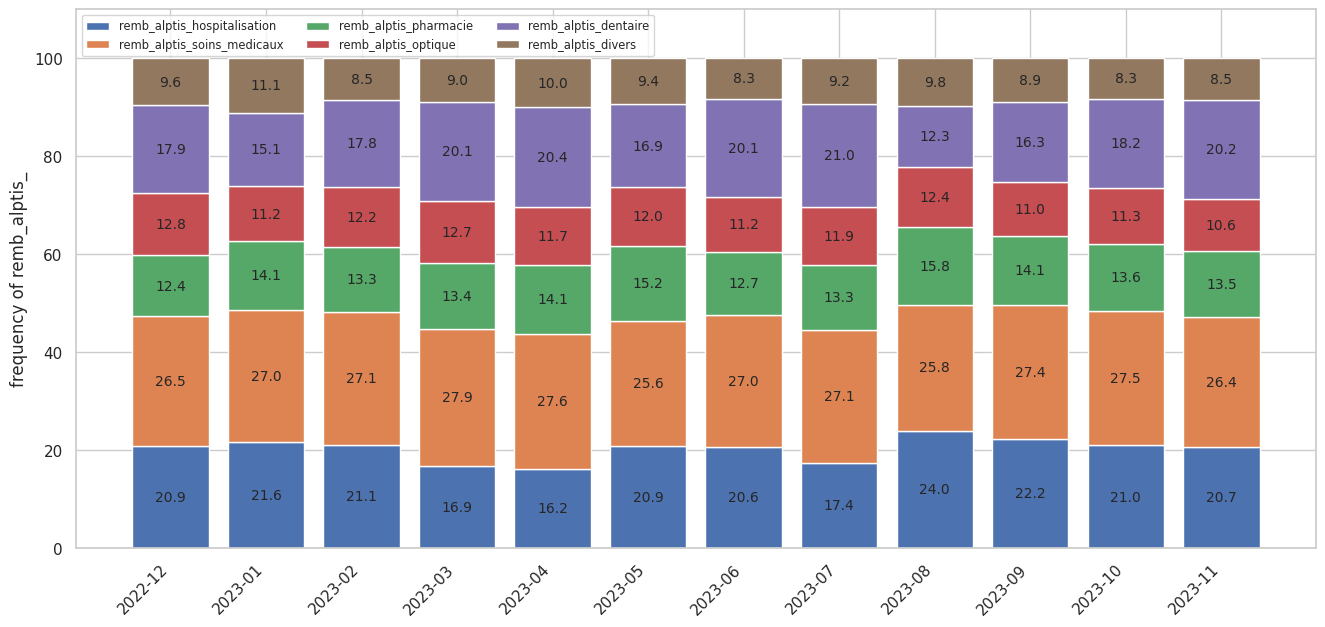

In [19]:
# Plotting the dataset - Analyse des décomptes
TransformData.stacked_bar(data=df_conso_datetime, variable_root_name='remb_alptis_', x_axis_variable='month-year', type_stack='classic')

Analyse préliminaire :

-   La distribution des remboursements est à peu près similaire à celle des décompte d'actes de santé, notamment au niveau des pics tous les trimestres et un mois de novembre relativement plus important.
-   Les hospitalisations qui représentent que 2% des décomptes réalisent 20% des remboursement. /!\ c'est u sujet à surveiller. 
-   Les soins médicaux comptent pour un peu plus d'un quart des remboursements. 
-   Pharmacie + optique = 1/4 - pas beaucoup

__

__

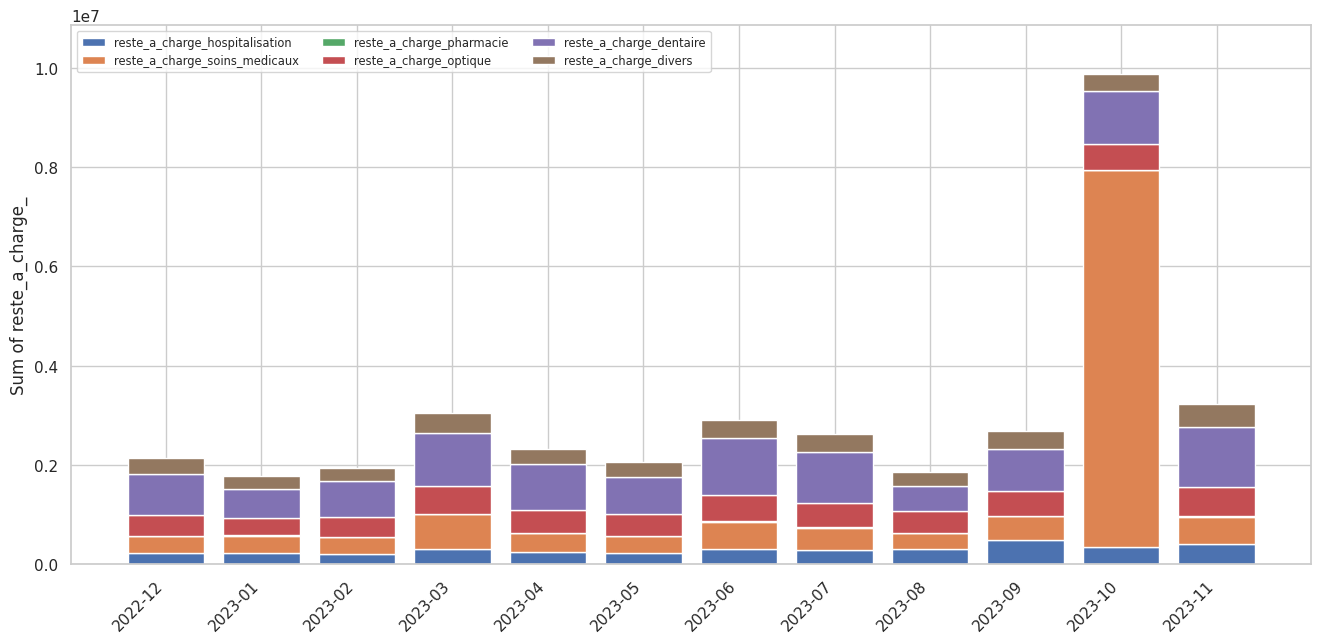

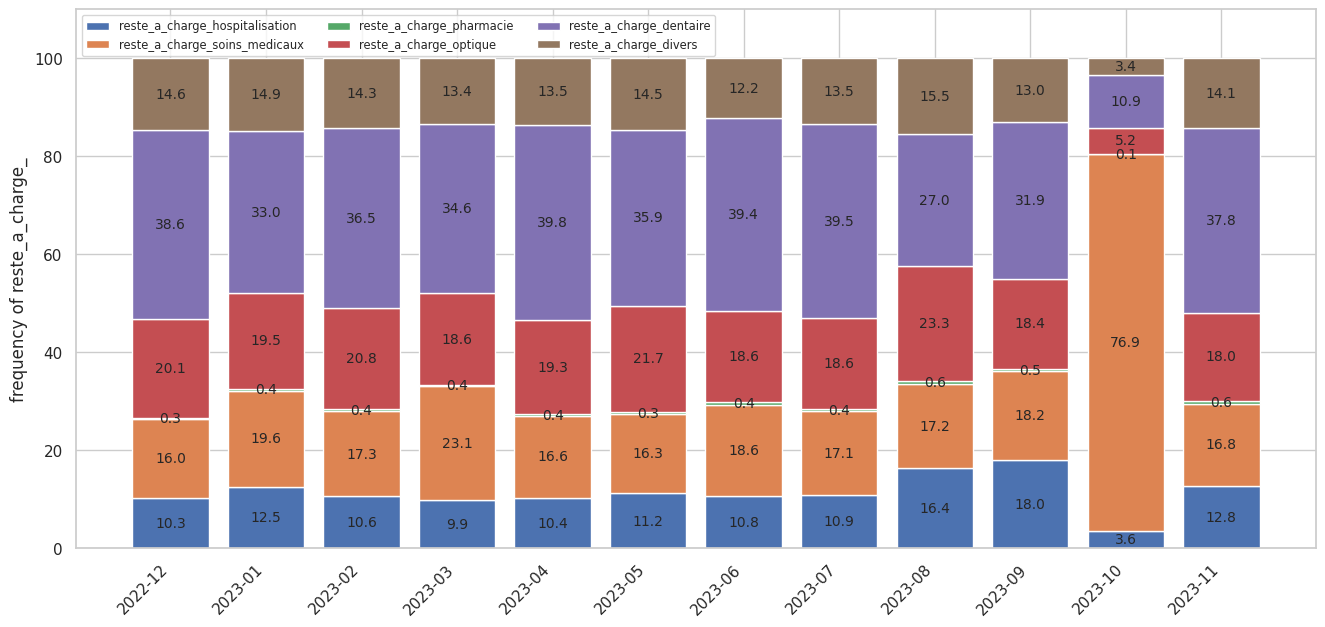

In [20]:
# Plotting the dataset - Analyse des décomptes
TransformData.stacked_bar(data=df_conso_datetime, variable_root_name='reste_a_charge_', x_axis_variable='month-year', type_stack='classic')

Analyse préliminaire :
-   Un montant anormalement élevé du reste à charge au mois d'octobre. Comprendre d'où cela vient. Effet individuel ou effet nombre de personnes nécessitant des soins médicaux.
-   Les dépenses dentaires sont les actes où le reste à charge est le plus élevé. Compter 30 à 40% du reste à charge en fonction du mois.
-   Les soins médicaux comptent pour 20% à peu près
-   Les reste à charge en pharmacie sont très faibles (moins de 1%)

__

#### Aggregating the dataset at the customer level

The goal of this section is to create an aggregated dataset with one line per customer. We are seeking to summarize on a single per customer line the entire information contained in the dataset, and proceed to a merge with the customer dataset.
The strategy will be as followed :
-   Taking the detailed variable instead of the sum
-   Reimbursement by Alptis (reimbursement by RO is not individual-specific, as it depends on regulations, frais reel correspond to the sum of reimbursement. No need to add it to the dataset)
-   Reste à charge

In [21]:
# Build the aggregated dataset
df_conso_aggregated_customer = df_conso[list_categorical + list_numerical].groupby(by='client_code').agg('sum').reset_index()
df_conso_aggregated_customer.drop(['nb_decomptes', 'remb_alptis', 'frais_reels', 'reste_a_charge'], axis=1, inplace=True)
df_conso_aggregated_customer.head()

,client_code,nb_decomptes_hospitalisation,nb_decomptes_soins_medicaux,nb_decomptes_pharmacie,nb_decomptes_optique,nb_decomptes_dentaire,nb_decomptes_divers,nb_jours_forfait_journalier,nb_jours_chambre_particuliere,nb_protheses_dentaires,...,frais_reels_pharmacie,frais_reels_optique,frais_reels_dentaire,frais_reels_divers,reste_a_charge_hospitalisation,reste_a_charge_soins_medicaux,reste_a_charge_pharmacie,reste_a_charge_optique,reste_a_charge_dentaire,reste_a_charge_divers
0,10000257,0,12,15,1,0,0,0,0,0,...,183.03,189.99,0.00,0.00,0.0,120.47,0.0,0.02,0.0,0.00
1,10000481,2,28,43,1,0,15,2,2,0,...,836.58,433.00,0.00,861.00,0.0,13.60,0.0,83.03,0.0,2.56
2,10000516,0,1,0,0,0,0,0,0,0,...,0.00,0.00,0.00,0.00,0.0,36.55,0.0,0.00,0.0,0.00
3,10000747,0,9,23,0,1,4,0,0,1,...,754.40,0.00,453.38,96.32,0.0,45.10,0.0,0.00,0.0,10.00
4,10001412,0,1,0,0,0,0,0,0,0,...,0.00,0.00,0.00,0.00,0.0,0.00,0.0,0.00,0.0,0.00


In [22]:
# Build the aggregated dataset
df_conso_aggregated_customer.shape

(120907, 35)

In [23]:
# Analyzing the correlations
list_numerical_prime = [x for x in list_numerical if x not in ['nb_decomptes', 'remb_alptis', 'frais_reels', 'reste_a_charge']]
#sns.pairplot(df_conso_aggregated_customer[list_numerical_prime])

In [24]:
# Analyzing the correlations
df_conso_aggregated_customer.corr(numeric_only=True)

,nb_decomptes_hospitalisation,nb_decomptes_soins_medicaux,nb_decomptes_pharmacie,nb_decomptes_optique,nb_decomptes_dentaire,nb_decomptes_divers,nb_jours_forfait_journalier,nb_jours_chambre_particuliere,nb_protheses_dentaires,remb_alptis_hospitalisation,...,frais_reels_pharmacie,frais_reels_optique,frais_reels_dentaire,frais_reels_divers,reste_a_charge_hospitalisation,reste_a_charge_soins_medicaux,reste_a_charge_pharmacie,reste_a_charge_optique,reste_a_charge_dentaire,reste_a_charge_divers
nb_decomptes_hospitalisation,1.000000,0.247831,0.228599,0.061073,0.042327,0.192405,0.627651,0.435558,0.026182,0.609980,...,0.100717,0.058315,0.032130,0.109889,0.230214,0.001449,0.021708,0.042031,0.020974,0.034990
nb_decomptes_soins_medicaux,0.247831,1.000000,0.586910,0.218172,0.308023,0.355984,0.022391,0.071261,0.087162,0.150043,...,0.237678,0.205235,0.139335,0.182023,0.089358,0.003609,0.079992,0.138290,0.093258,0.079833
nb_decomptes_pharmacie,0.228599,0.586910,1.000000,0.169024,0.237944,0.389957,0.028258,0.061661,0.101413,0.112515,...,0.382386,0.157583,0.130553,0.197556,0.059805,-0.000051,0.108871,0.109839,0.082150,0.085724
nb_decomptes_optique,0.061073,0.218172,0.169024,1.000000,0.160106,0.090380,-0.023858,0.000517,0.047384,0.011862,...,0.053943,0.840318,0.080543,0.045816,0.017095,-0.001055,0.028542,0.591725,0.049661,0.028295
nb_decomptes_dentaire,0.042327,0.308023,0.237944,0.160106,1.000000,0.102339,-0.039989,-0.004247,0.434047,0.006953,...,0.073890,0.152880,0.579664,0.053240,0.025236,-0.000965,0.036683,0.103742,0.366409,0.040764
nb_decomptes_divers,0.192405,0.355984,0.389957,0.090380,0.102339,1.000000,0.067839,0.079778,0.045993,0.124574,...,0.162961,0.093471,0.055953,0.442716,0.051234,0.000597,0.050757,0.067720,0.032182,0.100966
nb_jours_forfait_journalier,0.627651,0.022391,0.028258,-0.023858,-0.039989,0.067839,1.000000,0.516477,-0.005111,0.657911,...,0.025130,-0.024578,-0.013563,0.058191,0.078741,0.000124,-0.003239,-0.018289,-0.013649,0.013327
nb_jours_chambre_particuliere,0.435558,0.071261,0.061661,0.000517,-0.004247,0.079778,0.516477,1.000000,0.005536,0.708206,...,0.037079,0.003952,0.004088,0.059595,0.200644,0.001428,0.007640,0.002906,0.002087,0.012113
nb_protheses_dentaires,0.026182,0.087162,0.101413,0.047384,0.434047,0.045993,-0.005111,0.005536,1.000000,0.010941,...,0.037899,0.051480,0.822785,0.031294,0.010480,-0.000539,0.017355,0.033397,0.433915,0.016032
remb_alptis_hospitalisation,0.609980,0.150043,0.112515,0.011862,0.006953,0.124574,0.657911,0.708206,0.010941,1.000000,...,0.064082,0.017612,0.014677,0.088252,0.311612,0.000917,0.009660,0.014516,0.011705,0.019288


In [27]:
# Merging dataset with client one
inner, left, right = TransformData.dataframe_merge(input_df1=df_conso_aggregated_customer, input_df2=df_portfolio, id_1='client_code', id_2='client_code')

In [31]:
inner

,client_code,nb_decomptes_hospitalisation,nb_decomptes_soins_medicaux,nb_decomptes_pharmacie,nb_decomptes_optique,nb_decomptes_dentaire,nb_decomptes_divers,nb_jours_forfait_journalier,nb_jours_chambre_particuliere,nb_protheses_dentaires,...,courtier_code_avant_changement_12_mois,courtier_reseau_courtage,courtier_segmentation_interne,courtier_type_commission,courtier_est_escompte,courtier_nb_affaires_n_moins1,courtier_nb_radiations_n_moins1,courtier_nb_affaires_n_moins2,courtier_nb_radiations_n_moins2,target_resiliation_6mois
0,10000257,0,12,15,1,0,0,0,0,0,...,nan,COURTIER CLASSIQUE,VIP,precompte,0,18,11,21,9,0
1,10000481,2,28,43,1,0,15,2,2,0,...,nan,AFFAIRE DIRECTE,Alptis,precompte,1,1,80,2,112,0
2,10000516,0,1,0,0,0,0,0,0,0,...,nan,COURTIER CLASSIQUE,Potentiel,precompte,0,5,4,1,3,0
3,10000747,0,9,23,0,1,4,0,0,1,...,nan,COURTIER CLASSIQUE,VIP,lineaire,0,404,166,145,119,0
4,10001412,0,1,0,0,0,0,0,0,0,...,nan,COURTIER ESCOMPTE,Potentiel,precompte,1,1,8,1,8,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
120902,9998892,0,31,12,0,0,2,0,0,0,...,nan,COURTIER CLASSIQUE,Groupements,precompte,0,0,0,1,1,1
120903,9998990,0,5,1,4,0,0,0,0,0,...,nan,COURTIER CLASSIQUE,Groupements,precompte,0,0,0,1,1,0
120904,9999018,0,8,0,0,2,0,0,0,0,...,nan,E_COURTIER,CMA,precompte,0,3400,1908,2561,2141,1
120905,9999165,0,5,1,0,0,0,0,0,0,...,nan,COURTIER CLASSIQUE,VIP,lineaire,0,404,166,145,119,0
